# 20. Clasificacion de textos con BERT (BETO)

Este notebook resuelve **el mismo problema** que los notebooks `15`, `16`, `17` y `18`: clasificar el sentimiento de criticas de FilmAffinity en Negativa, Neutra o Positiva, pero en este casi vamos a usar un modelo BERT (base) ya preentrenado en español, concretamente usaremos **BETO** (`dccuchile/bert-base-spanish-wwm-cased`). 

Los pasos a realizar en este notebook son los siguientes: 

1. Cargar los datos
2. Normalización de los textos
3. Particionado de datos
4. Codificación del target
5. Tokenización con el tokenizador de BETO
6. Carga del modelo preentrenado de BETO
7. Fine-tuning: activamos el entrenamiento del cuerpo de BETO
8. Definición de la Red Neuronal completa
9. Entrenamiento del modelo
10. Evaluación del modelo


---

## 1. Carga de datos

Usamos `corpus/reviews_filmaffinity.csv`, concatenando el titulo y el cuerpo de la critica como texto de entrada, y derivando el sentimiento a partir de la nota numerica del usuario.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)   # hay que hacerlo ANTES de importar tensorflow: el WARNING de tf.losses.sparse_softmax_cross_entropy se dispara durante el propio import

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'       # silencia mensajes informativos de TensorFlow
os.environ['TF_USE_LEGACY_KERAS'] = '1'        # necesario para que transformers use tf_keras (Keras 2) en vez de Keras 3

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

import pandas as pd

df = pd.read_csv('corpus/reviews_filmaffinity.csv', sep='\|\|', engine='python')

# Descartamos las filas sin nota, ya que no podemos derivar el sentimiento
df = df.dropna(subset=['review_rate'])

# El texto de entrada es la concatenacion del titulo y el cuerpo de la critica
df['texto'] = df['review_title'].fillna('') + '. ' + df['review_text'].fillna('')

# Derivamos el sentimiento a partir de la nota numerica (review_rate)
def nota_a_sentimiento(nota):
    if nota <= 4:
        return 'Negativa'
    elif nota <= 6:
        return 'Neutra'
    else:
        return 'Positiva'

df['sentimiento'] = df['review_rate'].apply(nota_a_sentimiento)

print(f'Total de criticas: {len(df)}')
print()
print('Distribucion por sentimiento:')
print(df['sentimiento'].value_counts())
print()
print((df['sentimiento'].value_counts(normalize=True) * 100).round(1))



Total de criticas: 8601

Distribucion por sentimiento:
sentimiento
Positiva    3920
Negativa    2447
Neutra      2234
Name: count, dtype: int64

sentimiento
Positiva    45.6
Negativa    28.5
Neutra      26.0
Name: proportion, dtype: float64


---

## 2. Normalizacion de los textos

Aqui la decision es distinta a la de los notebooks 16, 17 y 18. Alli aplicabamos una normalizacion ligera (solo minusculas y espacios limpios) porque el embedding `nnlm-es-dim128` es insensible a mayusculas. 

**BETO es un modelo *cased*** (`bert-base-spanish-wwm-cased`): su vocabulario y su preentrenamiento distinguen mayusculas de minusculas, precisamente para aprovechar esa senal (nombres propios, inicios de frase, siglas, etc.). Pasarle el texto en minusculas seria alejarlo del lenguaje con el que se entreno, igual que ocurria si lematizabamos o quitabamos *stopwords* para un embedding.

Por tanto, aqui la normalizacion se limita a limpiar espacios en blanco, sin tocar mayusculas ni acentos: dejamos que sea el propio tokenizador de BETO (WordPiece) el que se encargue de partir el texto en subpalabras.

In [2]:
def normalizar(texto):
    '''Normalizacion minima para BETO: solo espacios limpios, sin tocar mayusculas (modelo cased).'''
    return ' '.join(texto.strip().split())

X = [normalizar(texto) for texto in df['texto'].tolist()]
y = df['sentimiento'].tolist()

print('Original:   ', df['texto'].iloc[0][:200], '...')
print('\nNormalizado:', X[0][:200], '...')


Original:    OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO. La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y l ...

Normalizado: OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO. La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y l ...


---

## 3. Particionado de datos (Train y Test)

Igual que en los notebooks anteriores, un 80/20 estratificado por sentimiento.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Criticas de entrenamiento: {len(X_train)}')
print(f'Criticas de test:          {len(X_test)}')


Criticas de entrenamiento: 6880
Criticas de test:          1721


---

## 4. Codificacion del target

Igual que en los notebooks anteriores, codificamos las tres clases con `LabelEncoder`.

In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(y_train)
y_train_enc = encoder.transform(y_train)
y_test_enc  = encoder.transform(y_test)

print(f'Clases codificadas: {list(encoder.classes_)}')


Clases codificadas: [np.str_('Negativa'), np.str_('Neutra'), np.str_('Positiva')]


---

## 5. Tokenizacion con el tokenizador de BETO

A diferencia de los notebooks 16-18, aqui no construimos nosotros el vocabulario: usamos el `AutoTokenizer` de la libreria `transformers`, que carga el tokenizador **WordPiece** con el que se preentreno BETO. 

Cada texto se convierte en `input_ids` (los identificadores de sus subpalabras) y en `attention_mask` (que marca que posiciones son texto real y cuales son *padding*), ademas de anadir los tokens especiales `[CLS]` (inicio, sera nuestro vector de resumen) y `[SEP]` (fin).

BETO, como la mayoria de modelos BERT base, tiene un limite de 512 posiciones (`max_position_embeddings`). A diferencia de los ejemplos anteriores, vamos a usar como tamaño de la secuencia las 512 posiciones (`MAX_LEN = 512`).

In [5]:
import numpy as np
from transformers import AutoTokenizer

MODELO = 'dccuchile/bert-base-spanish-wwm-cased'   # BETO: BERT en espanol

tokenizer = AutoTokenizer.from_pretrained(MODELO)

longitudes = np.array([len(tokenizer.encode(texto)) for texto in X_train])
percentiles = [50, 75, 90, 95, 99]
tabla_percentiles = pd.DataFrame({
    'Percentil': [f'p{p}' for p in percentiles],
    'Longitud (tokens)': [int(np.percentile(longitudes, p)) for p in percentiles]
})
print(tabla_percentiles.to_string(index=False))
print(f'\nMaximo: {longitudes.max()} tokens (limite del modelo: 512)')


Token indices sequence length is longer than the specified maximum sequence length for this model (519 > 512). Running this sequence through the model will result in indexing errors


Percentil  Longitud (tokens)
      p50                238
      p75                393
      p90                576
      p95                671
      p99               1023

Maximo: 1454 tokens (limite del modelo: 512)


Con `MAX_LEN=512` cubrimos algo menos del 90% de las criticas sin truncar.

In [6]:
MAX_LEN = 512

enc_train = tokenizer(X_train, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='tf')
enc_test  = tokenizer(X_test,  padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='tf')

print(f'Cobertura sin truncar con MAX_LEN={MAX_LEN}: {(longitudes <= MAX_LEN).mean() * 100:.1f}%')
print(f'Forma de input_ids (train): {enc_train["input_ids"].shape}')
print(f'\nTexto:      {X_train[0][:120]} ...')
print(f'input_ids:  {enc_train["input_ids"][0][:20].numpy()}')
print(f'tokens:     {tokenizer.convert_ids_to_tokens(enc_train["input_ids"][0][:20].numpy())}')


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Cobertura sin truncar con MAX_LEN=512: 85.7%
Forma de input_ids (train): (6880, 512)

Texto:      Popurrí Alejandrino. La verdad es Ágora prometía desde que se vieron las primeras imágenes. Tras un comienzo magnífico e ...
input_ids:  [    4 20861  1284  7395 11585  2174 16367  1009  1198  1836  1058  1003
  2393 30932 18687 30932  1668  1038  1062 10653]
tokens:     ['[CLS]', 'Pop', '##ur', '##rí', 'Alej', '##and', '##rino', '.', 'La', 'verdad', 'es', 'Á', '##gor', '##a', 'prometí', '##a', 'desde', 'que', 'se', 'vieron']


---

## 6. Carga del cuerpo preentrenado de BETO

Cargamos el modelo con `TFAutoModel`. 


In [7]:
from transformers import TFAutoModel
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

bert = TFAutoModel.from_pretrained(MODELO) # MODELO = 'dccuchile/bert-base-spanish-wwm-cased'

print(f'Parametros del cuerpo de BETO: {bert.num_parameters():,}')
print(f'Dimension del vector de resumen [CLS] (hidden_size): {bert.config.hidden_size}')


Parametros del cuerpo de BETO: 109,850,880
Dimension del vector de resumen [CLS] (hidden_size): 768


---

## 7. Elegir si se hace fine-tuning del cuerpo de BETO

El parámetros `bert.trainable` define si BERT se puede **fine-tunear** junto con la cabeza clasificadora, o bien **congelarse** y usarse solo como extractor de características. En este notebook se puede elegir cualquiera de las dos opciones con una única variable:

```python
FINE_TUNE_BERT = False   # True: se ajustan tambien los 109,85 millones de parametros del cuerpo de BETO
```

Ambas opciones comparten exactamente la misma red (sección 8); la única diferencia es si `bert.trainable` se fija a `True` o a `False`. 

Con el cuerpo de BETO congelado, cada paso solo calcula el gradiente de la cabeza clasificadora (los ~197K parámetros de la sección 8); con el cuerpo entrenable, hay que ajustar (entrenar) los 110M de parámetros de BETO, de que los tiempos de entrenamiento sean de minutos u horas en función de si se entrena BETO o no.

Dado que es una notebook didáctico cuyo fin es mostrar un ejemplo de aplicación de uso de un modelo BERT, vamos a dejar en `False` el parámetros `bert.trainable`. Si se dispone de una GPU probar a entrenar el modelo BETO para ver las diferencias.

In [8]:
FINE_TUNE_BERT = False   # True: se ajustan tambien los 110M de parametros del cuerpo de BETO

bert.trainable = FINE_TUNE_BERT

print(f'bert.trainable = {bert.trainable}')


bert.trainable = False


---

## 8. Definición de la Red Neuronal completa

La red se define de una sola vez, de principio a fin, tanto si `FINE_TUNE_BERT` es `True` como si es `False`: las entradas son directamente `input_ids` y `attention_mask` (los que genera el tokenizador en la sección 5), la propia red los pasa por el cuerpo de BETO, se queda con el vector `[CLS]` de `last_hidden_state[:, 0, :]` (768 posiciones, ver sección 6) y lo pasa por la misma cabeza clasificadora de la imagen: `Dropout` -> `Dense` de 256 neuronas con activación ReLU -> `Dropout` -> `Dense` de salida con `softmax`.

El `learning_rate` también depende de `FINE_TUNE_BERT`: si se hace fine-tuning usamos `2e-5` (un valor bajo, habitual para no destruir los pesos preentrenados del cuerpo en los primeros pasos); si el cuerpo está congelado, sus pesos no cambian independientemente del `learning_rate` que se use, así que dejamos el valor por defecto de Adam (`1e-3`), igual que en los notebooks 15-18, para que la cabeza clasificadora converja en pocas epochs.

In [9]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Dropout

tf.keras.utils.set_random_seed(42)   # fija a la vez las semillas de Python, NumPy y TensorFlow
tf.config.experimental.enable_op_determinism()   # evita variaciones por el orden de operaciones en coma flotante entre ejecuciones

input_ids = Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
attention_mask = Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

salida_bert = bert(input_ids=input_ids, attention_mask=attention_mask)
cls_vector = salida_bert.last_hidden_state[:, 0, :]

x = Dropout(0.2)(cls_vector)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=[input_ids, attention_mask], outputs=output)

learning_rate = 2e-5 if FINE_TUNE_BERT else 1e-3
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=['accuracy'])

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 512)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 512)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   1098508   ['input_ids[0][0]',           
 )                           ngAndCrossAttentions(last_   80         'attention_mask[0][0]']      
                             hidden_state=(None, 512, 7                                       

---

## 9. Entrenamiento del modelo

Igual que en los notebooks 15-18: pesos por clase para compensar el desbalanceo, y el callback `F1Checkpoint` que se queda con el modelo del epoch con mejor F1 ponderado en test. `fit()` recibe directamente `[input_ids, attention_mask]` en vez de un vector ya calculado.


In [10]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score

pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = {clase: peso for clase, peso in zip(np.unique(y_train_enc), pesos)}
print('Pesos por clase:', class_weight_dict)


class F1Checkpoint(Callback):
    '''Igual que en los notebooks 15-18: registra el F1 ponderado de train/test y guarda el mejor modelo.'''

    def __init__(self, filepath, X_train, y_train_enc, X_val, y_val_enc):
        super().__init__()
        self.filepath = filepath
        self.X_train = X_train
        self.y_train_enc = y_train_enc
        self.X_val = X_val
        self.y_val_enc = y_val_enc
        self.best_f1 = -1.0
        self.f1_train_history = []
        self.f1_val_history = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred_train_enc = np.argmax(self.model.predict(self.X_train, verbose=0), axis=-1)
        y_pred_val_enc   = np.argmax(self.model.predict(self.X_val, verbose=0), axis=-1)

        f1_train = f1_score(self.y_train_enc, y_pred_train_enc, average='weighted')
        f1_val   = f1_score(self.y_val_enc, y_pred_val_enc, average='weighted')

        self.f1_train_history.append(f1_train)
        self.f1_val_history.append(f1_val)

        if f1_val > self.best_f1:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> mejora, guardando modelo en {self.filepath}')
            self.best_f1 = f1_val
            self.model.save(self.filepath)
        else:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> no mejora el mejor val_f1 ({self.best_f1:.4f})')


MODEL_PATH = 'models/20_mejor_modelo_bert_beto_reviews.keras'

X_train_inputs = [enc_train['input_ids'], enc_train['attention_mask']]
X_test_inputs  = [enc_test['input_ids'], enc_test['attention_mask']]

checkpoint_f1 = F1Checkpoint(
    filepath=MODEL_PATH,
    X_train=X_train_inputs, y_train_enc=y_train_enc,
    X_val=X_test_inputs, y_val_enc=y_test_enc)


Pesos por clase: {np.int64(0): np.float64(1.1718616930676204), np.int64(1): np.float64(1.2833426599515017), np.int64(2): np.float64(0.7312925170068028)}


In [11]:
history = model.fit(
    X_train_inputs, y_train_enc,
    batch_size=32,
    epochs=5,
    verbose=1,
    validation_data=(X_test_inputs, y_test_enc),
    class_weight=class_weight_dict,
    callbacks=[checkpoint_f1])

history.history['f1'] = checkpoint_f1.f1_train_history
history.history['val_f1'] = checkpoint_f1.f1_val_history


Epoch 1/5
215/215 [==============================] - ETA: 0s - loss: 0.9591 - accuracy: 0.5519 
Epoch 1: f1: 0.6164 - val_f1: 0.6242 -> mejora, guardando modelo en models/20_mejor_modelo_bert_beto_reviews.keras
215/215 [==============================] - 7729s 36s/step - loss: 0.9591 - accuracy: 0.5519 - val_loss: 0.8287 - val_accuracy: 0.6089
Epoch 2/5
215/215 [==============================] - ETA: 0s - loss: 0.8795 - accuracy: 0.5942 
Epoch 2: f1: 0.6639 - val_f1: 0.6593 -> mejora, guardando modelo en models/20_mejor_modelo_bert_beto_reviews.keras
215/215 [==============================] - 7964s 37s/step - loss: 0.8795 - accuracy: 0.5942 - val_loss: 0.7694 - val_accuracy: 0.6543
Epoch 3/5
215/215 [==============================] - ETA: 0s - loss: 0.8520 - accuracy: 0.6084 
Epoch 3: f1: 0.6632 - val_f1: 0.6601 -> mejora, guardando modelo en models/20_mejor_modelo_bert_beto_reviews.keras
215/215 [==============================] - 7314s 34s/step - loss: 0.8520 - accuracy: 0.6084 - val_l

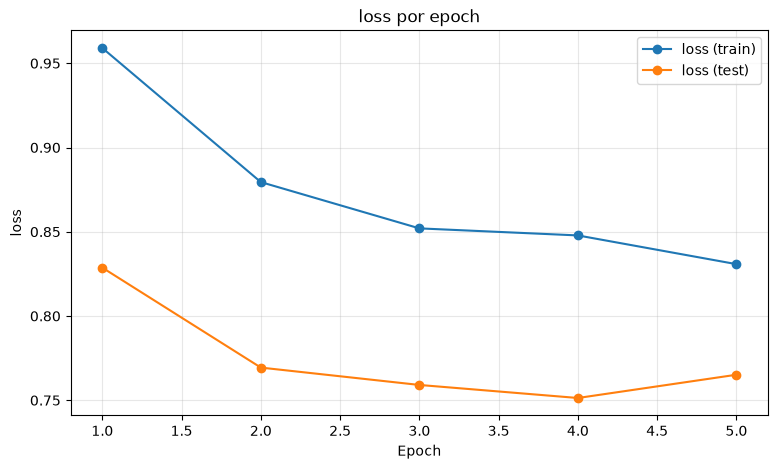

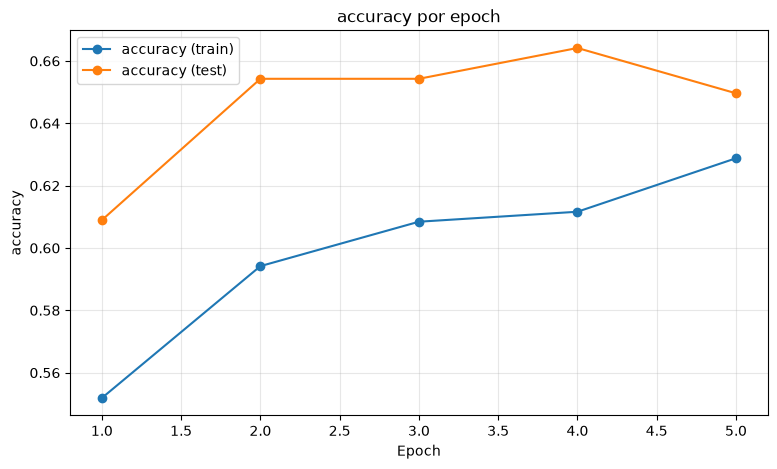

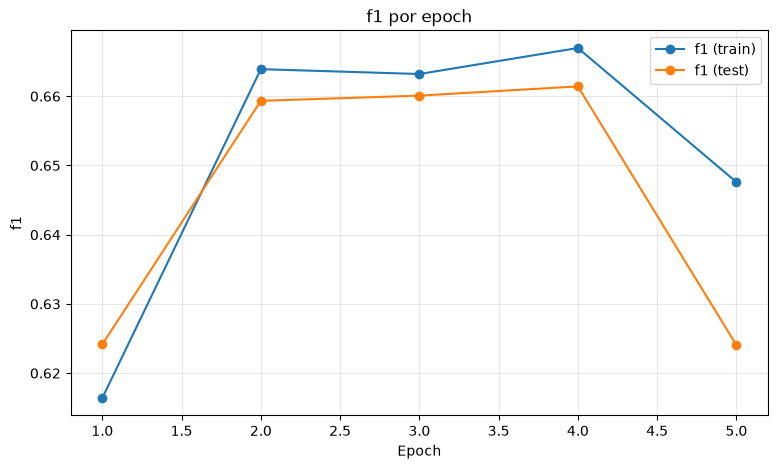

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_metric(history, name):
    metric_train = history.history[name]
    metric_test  = history.history[f'val_{name}']
    epochs_range = range(1, len(metric_train) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs_range, metric_train, marker='o', label=f'{name} (train)')
    plt.plot(epochs_range, metric_test, marker='o', label=f'{name} (test)')
    plt.title(f'{name} por epoch')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

plot_metric(history, 'loss')
plot_metric(history, 'accuracy')
plot_metric(history, 'f1')


---

## 10. Evaluacion del modelo

Cargamos el modelo del epoch con mejor `val_f1` y lo evaluamos sobre test, igual que en los notebooks 15-18.

In [14]:
from tensorflow.keras.models import load_model
from transformers import TFAutoModel, TFBertModel # Import TFAutoModel and TFBertModel for custom_objects

modelo_bert = load_model(MODEL_PATH, custom_objects={'TFBertModel': TFBertModel})
print(f'Modelo cargado desde: {MODEL_PATH}')


Modelo cargado desde: models/20_mejor_modelo_bert_beto_reviews.keras


In [15]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, ConfusionMatrixDisplay)

y_pred_test_enc  = np.argmax(modelo_bert.predict(X_test_inputs), axis=-1)
y_pred_train_enc = np.argmax(modelo_bert.predict(X_train_inputs), axis=-1)

y_pred_test  = encoder.inverse_transform(y_pred_test_enc)
y_pred_train = encoder.inverse_transform(y_pred_train_enc)

print('--- Evaluacion en TEST ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_test, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_test))


215/215 [==============================] - 2910s 14s/step
--- Evaluacion en TEST ---
Accuracy:  0.6641
Precision: 0.6629
Recall:    0.6641
F1:        0.6614

              precision    recall  f1-score   support

    Negativa       0.72      0.61      0.66       490
      Neutra       0.47      0.47      0.47       447
    Positiva       0.73      0.81      0.77       784

    accuracy                           0.66      1721
   macro avg       0.64      0.63      0.63      1721
weighted avg       0.66      0.66      0.66      1721



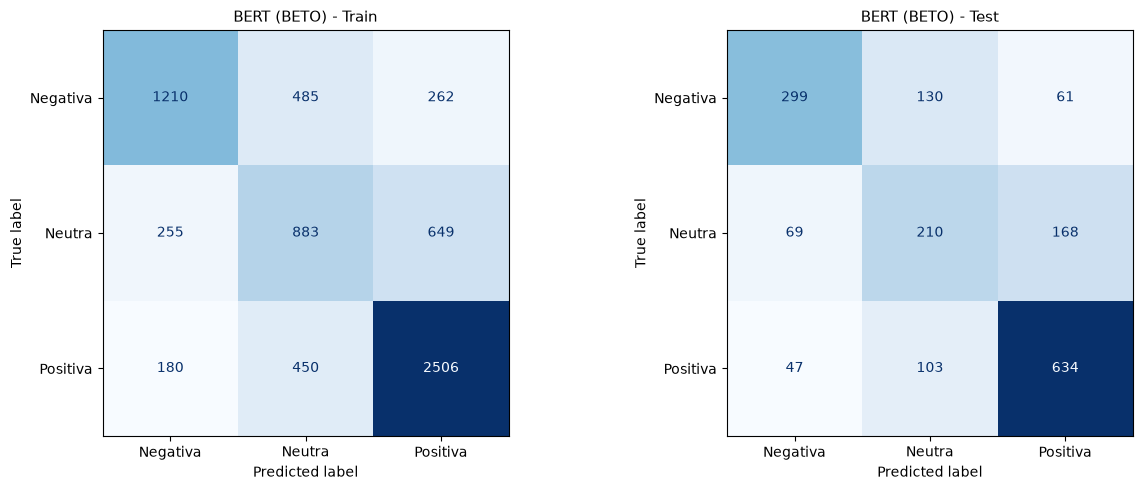

In [16]:
clases = list(encoder.classes_)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[0])
axes[0].set_title('BERT (BETO) - Train', fontsize=11)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[1])
axes[1].set_title('BERT (BETO) - Test', fontsize=11)

plt.tight_layout()
plt.show()


## Conclusiones

* El `F1Checkpoint` se quedó con el modelo del **epoch 4** (val_f1 = 0.6614), con el cuerpo de BETO congelado. En test obtiene un **accuracy del 66.41 % y un F1 ponderado de 0.6614**, con un F1 de Neutra de 0.47:

    | Notebook | Representación | Accuracy | F1 | F1 Negativa | F1 Neutra | F1 Positiva |
    |---|---|---|---|---|---|---|
    | 15 | Bag of Words (3.000 dim.) | 67.40 % | 0.6763 | 0.68 | 0.50 | 0.78 |
    | 16 | Embedding `nnlm-es-dim128` (documento) | 69.26 % | 0.6931 | 0.69 | 0.52 | 0.79 |
    | 17 | Embedding `nnlm-es-dim128` (por palabra) + LSTM bidireccional | 67.98 % | 0.6805 | 0.71 | 0.49 | 0.77 |
    | 18 | Embedding `nnlm-es-dim128` (por palabra) + 2 bloques Transformer | 65.72 % | 0.6663 | 0.63 | 0.52 | 0.78 |
    | 20 | BERT (BETO), cuerpo congelado | 66.41 % | 0.6614 | 0.66 | 0.47 | 0.77 |
    | **20 (Colab)** | **BERT (BETO), fine-tuning completo (GPU)** | **75.60 %** | **0.7562** | 0.74 | 0.61 | 0.85 |

* Con el cuerpo congelado, BETO queda por debajo de las otras cuatro técnicas: el vector `[CLS]` es una representación genérica, aprendida con enmascaramiento de palabras (MLM) sobre un corpus general, y la cabeza clasificadora (solo ~197.000 parámetros) tiene que separar el sentimiento a partir de esa representación fija, sin poder ajustarla a la tarea.

* La fila del notebook de Colab (mismo ejercicio, enlace en el README) corresponde a entrenar la misma red con `bert.trainable = True` y GPU: es el mejor resultado de los seis, con el mayor salto respecto al resto en la clase más difícil, Neutra.

* La diferencia se explica por lo mismo que limitaba a la versión congelada: al permitir el fine-tuning, el gradiente fluye por las 12 capas de BETO, que dejan de estar fijadas a una representación general del lenguaje y se reorganizan para separar mejor las señales de sentimiento (adjetivos, negaciones, intensificadores) en el vector `[CLS]`. Con el cuerpo congelado esa reorganización es imposible: solo se puede trabajar con la representación ya dada.

* Esta mejora tiene un coste computacional que solo es asumible con GPU: en esta misma máquina (CPU), cada epoch con el cuerpo congelado tardó más de 2 horas; entrenar además los 110M de parámetros de BETO habría sido inviable sin GPU. Por eso este notebook mantiene `bert.trainable = False` por defecto, y la comparación con el fine-tuning completo se hace en la versión de Colab.